# 모델 설정값(하이퍼파라미터) 최적화

## 학습 목표

1. 하이퍼파라미터의 개념과 모델 성능에 미치는 영향을 이해한다
2. GridSearchCV로 체계적인 최적값 탐색을 수행한다
3. RandomizedSearchCV로 효율적인 대규모 탐색을 수행한다
4. 실제 제조/산업 데이터에 하이퍼파라미터 튜닝을 적용한다

## 실습 데이터셋: Scania Trucks APS Failure Data

**APS (Air Pressure System) Failure Dataset**은 스웨덴의 대형 트럭 제조사 Scania가 실제 운행 중인 트럭에서 수집한 산업 데이터임.
UCI Machine Learning Repository에서 제공하며, 2016년 IDA(Intelligent Data Analysis) 국제 학술대회의 산업 챌린지 데이터로 사용된 적이 있음.

### 데이터셋 기본 정보

| 항목 | 설명 |
|------|------|
| 출처 | UCI Machine Learning Repository (Scania CV AB) |
| 학습 샘플 수 | 60,000개 (정상 59,000 / 고장 1,000) |
| 테스트 샘플 수 | 16,000개 |
| 특성 수 | 170개 (익명화된 센서 및 카운터 데이터) |
| 타겟 | APS 시스템 고장 여부 (neg: 정상, pos: APS 고장) |
| 특징 | 심각한 클래스 불균형 (1.67%), 다수의 결측치 |

### Air Pressure System (APS)이란?

APS는 트럭의 핵심 안전 시스템으로, 압축 공기를 생성하여 다음과 같은 기능을 담당:

- **제동 시스템 (Braking)**: 에어 브레이크 작동
- **기어 변속 (Gear Changes)**: 변속기 제어
- **서스펜션 조절**: 에어 서스펜션 시스템

APS 고장은 트럭 운행 중 심각한 안전 문제를 야기할 수 있어, 사전 예측을 통한 예방 정비가 매우 중요.

### 비용 기반 평가 (Cost-Sensitive Evaluation)

이 데이터셋의 특별한 점은 **비용 함수**가 이미 정의되어 있어 본 실습에 활용하기에 적절함:

| 오류 유형 | 설명 | 비용 |
|----------|------|------|
| Type 1 (False Positive) | 정상 트럭을 고장으로 오진 -> 불필요한 정비 | **10 USD** |
| Type 2 (False Negative) | 고장 트럭을 정상으로 오진 -> 운행 중 고장 발생 | **500 USD** |

$$\text{Total Cost} = 10 \times FP + 500 \times FN$$

이러한 비용 구조는 실제 제조/운송 현장의 의사결정을 반영할 수 있음.
일전 언급하였듯 고장을 놓치는 것(FN)이 불필요한 점검(FP)보다 비용이 훨씬 크게 발생할 수 있음.

### 제조 현장 적용 의의

- **예방 정비 (Predictive Maintenance)**: 고장 전 사전 감지로 다운타임 최소화
- **비용 최적화**: 불필요한 점검 비용 vs 고장 비용의 균형
- **고차원 데이터 처리**: 170개 센서 데이터에서 핵심 패턴 추출
- **불균형 데이터**: 실제 산업 현장의 희소 이벤트 처리 경험

# Part 1: 하이퍼파러미터

## 1.1 하이퍼파라미터란?

머신러닝 모델을 학습시킬 때, 우리는 두 가지 종류의 "설정값"을 다루게 됨. 

이 둘을 명확히 구분할 수 있어야 함!

### 파라미터(Parameter) vs 하이퍼파라미터(Hyperparameter)

```mermaid
flowchart LR
    subgraph 모델학습과정
        A["학습 데이터"] --> B["학습 알고리즘"]
        B --> C["파라미터 (자동 학습)<br/>- 회귀 가중치 w, b<br/>- 트리 분할 기준값<br/>- 신경망 가중치"]
    end
    
    subgraph 사전설정
        D["사람이 설정"] --> E["하이퍼파라미터<br/>- max_depth<br/>- n_estimators<br/>- learning_rate"]
        E --> B
    end
    
    style C fill:#dcfce7
    style E fill:#fef3c7
```

| 구분 | 파라미터 (Parameter) | 하이퍼파라미터 (Hyperparameter) |
|------|---------------------|-------------------------------|
| **정의** | 모델이 학습 과정에서 데이터로부터 찾아내는 값 | 사람이 학습을 시작하기 전에 미리 지정하는 값 |
| **결정 시점** | 학습 중 자동 결정 | 학습 시작 전에 결정 |
| **결정 방법** | 경사하강법, 분할 알고리즘 등 | Grid Search, Random Search, 경험적 선택 |
| **예시** | 선형회귀의 가중치 $w$, 절편 $b$ | `max_depth`, `n_estimators`, `learning_rate` |

요리에 비유하면, **파라미터**는 요리하면서 간을 맞추는 것(소금의 양)이고,

**하이퍼파라미터**는 요리를 시작하기 전에 결정하는 조리 방법(끓이기, 굽기, 튀기기).

조리 방법을 잘못 선택하면 아무리 간을 잘 맞춰도 요리는 망함

### 주요 모델별 하이퍼파라미터

각 머신러닝 알고리즘은 고유한 하이퍼파라미터를 가지고 있음:

```mermaid
flowchart TD
    A["하이퍼파라미터"]

    A --> B["의사결정나무<br/>DecisionTree"]
    B --> B1["max_depth: 트리 최대 깊이"]
    B --> B2["min_samples_split: 분할 최소 샘플 수"]
    B --> B3["min_samples_leaf: 리프 노드 최소 샘플 수"]

    A --> C["랜덤포레스트<br/>RandomForest"]
    C --> C1["n_estimators: 트리 개수"]
    C --> C2["max_features: 분할 시 고려할 특성 수"]
    C --> C3["max_depth: 개별 트리의 최대 깊이"]

    A --> D["그래디언트 부스팅<br/>GradientBoosting"]
    D --> D1["learning_rate: 학습률"]
    D --> D2["n_estimators: 부스팅 단계 수"]
    D --> D3["max_depth: 개별 트리 깊이"]

    style A fill:#1e40af,color:#fff
    style B fill:#dbeafe
    style C fill:#dcfce7
    style D fill:#fef3c7
```

#### RandomForest의 주요 하이퍼파라미터 상세

| 하이퍼파라미터 | 의미 | 기본값 | 영향 |
|---------------|------|--------|------|
| `n_estimators` | 앙상블에 사용할 트리 개수 | 100 | 많을수록 안정적이나 학습 시간 증가 |
| `max_depth` | 각 트리의 최대 깊이 | None (무제한) | 깊을수록 복잡한 패턴 학습, 과적합 위험 |
| `min_samples_split` | 노드 분할에 필요한 최소 샘플 수 | 2 | 클수록 과적합 방지, 단순한 모델 |
| `min_samples_leaf` | 리프 노드의 최소 샘플 수 | 1 | 클수록 과적합 방지 |
| `max_features` | 분할 시 고려할 특성 수 | 'sqrt' | 다양성 vs 개별 트리 성능 균형 |
| `class_weight` | 클래스별 가중치 | None | 불균형 데이터 대응 |

### 하이퍼파라미터가 성능에 미치는 영향: 과소적합과 과대적합

하이퍼파라미터 설정은 모델의 **복잡도(complexity)** 를 결정하며, 이는 곧 과소적합과 과대적합 사이의 균형에 영향을 끼침

```mermaid
flowchart LR
    A["모델 복잡도"] --> B["낮음<br/>(과소적합)"]
    A --> C["적절함<br/>(최적)"]
    A --> D["높음<br/>(과대적합)"]
    
    B --> B1["max_depth=2<br/>학습: 0.75\n테스트: 0.72"]
    C --> C1["max_depth=8<br/>학습: 0.92\n테스트: 0.89"]
    D --> D1["max_depth=None<br/>학습: 1.00\n테스트: 0.82"]
    
    style B fill:#fecaca
    style C fill:#bbf7d0
    style D fill:#fef08a
```

| 상태 | 학습 점수 | 테스트 점수 | 원인 | 해결책 |
|------|-----------|-------------|------|--------|
| **과소적합** | 낮음 | 낮음 | 모델이 너무 단순 | 복잡도 증가 (max_depth 증가, n_estimators 증가) |
| **적절함** | 높음 | 높음 (비슷) | 적절한 균형 | 현재 설정 유지 |
| **과대적합** | 매우 높음 | 낮음 | 모델이 너무 복잡, 학습 데이터 암기 | 복잡도 감소, 정규화 강화 |

## 1.2 수학적 배경: 탐색 공간과 최적화

### 탐색 공간의 크기 (Search Space Size)

하이퍼파라미터 튜닝의 핵심 도전은 **탐색 공간의 기하급수적 증가**. GridSearchCV에서 탐색해야 할 전체 조합의 수는 각 하이퍼파라미터 후보값 개수의 **곱**으로 계산됨

$$|S| = \prod_{i=1}^{k}|P_i|$$

여기서:
- $|S|$: 전체 탐색 공간의 크기 (총 조합 수)
- $k$: 하이퍼파라미터의 개수
- $|P_i|$: $i$번째 하이퍼파라미터의 후보값 개수

**예시 계산:**

만약 다음과 같이 탐색 범위를 정의한다면:

```python
param_grid = {
    'n_estimators': [50, 100, 150, 200],     # |P1| = 4
    'max_depth': [3, 5, 7, 10, None],        # |P2| = 5
    'min_samples_split': [2, 5, 10],         # |P3| = 3
    'min_samples_leaf': [1, 2, 4]            # |P4| = 3
}
```

$$|S| = 4 \times 5 \times 3 \times 3 = 180 \text{ 조합}$$

5-Fold 교차검증을 적용하면: $180 \times 5 = 900$회의 모델 학습이 필요

만약 하이퍼파라미터를 하나 더 추가하고 각각 5개의 후보값을 가진다면: $180 \times 5 = 900$ 조합으로 급증하게 됨. 이것이 **차원의 저주(Curse of Dimensionality)**가 하이퍼파라미터 튜닝에서도 나타나는 이유 

*(참조: 시계열 파트의 PCA 부분도 참조)*

### 교차검증 평균 점수 (Cross-Validation Mean Score)

GridSearchCV와 RandomizedSearchCV는 각 하이퍼파라미터 조합을 **교차검증(Cross-Validation)** 을 통해 자동화되어 판단함. 이는 모델의 일반화 성능을 더 신뢰성 있게 추정할 수 있게 도와줌

$$\bar{CV} = \frac{1}{k}\sum_{i=1}^{k}Score_i$$

여기서:
- $\bar{CV}$: 교차검증 평균 점수
- $k$: Fold 수 (일반적으로 5 또는 10)
- $Score_i$: $i$번째 Fold에서의 검증 점수

**표준편차의 중요성:**

평균 점수만큼 중요한 것이 **표준편차**. 표준편차가 큰 모델은 특정 데이터 분할에 민감하여 신뢰하기 어려움.

$$\sigma_{CV} = \sqrt{\frac{1}{k}\sum_{i=1}^{k}(Score_i - \bar{CV})^2}$$

**5-Fold 교차검증 예시:**

```
조합 A: Fold 점수 = [0.87, 0.89, 0.86, 0.88, 0.90]
        평균 = 0.88, 표준편차 = 0.014  -> 안정적
        
조합 B: Fold 점수 = [0.95, 0.75, 0.90, 0.82, 0.88]
        평균 = 0.86, 표준편차 = 0.072  -> 불안정
```

평균만 보면 조합 B(0.86)가 조합 A(0.88)보다 약간 낮지만, 표준편차를 함께 고려하면 조합 A가 훨씬 더 신뢰할 수 있는 선택으로 보이지 않는지?

### 학습률(Learning Rate)과 경사하강법

많은 머신러닝 알고리즘(GradientBoosting, 신경망 등)에서 **학습률(learning rate)** 은 가장 중요한 하이퍼파라미터 중 하나임(*딥러닝 파트에서 다시 볼 용어*).

학습률은 경사하강법에서 각 스텝의 크기를 결정:

$$\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)$$

여기서:
- $\theta_t$: 시점 $t$에서의 파라미터 벡터 (모델이 학습하는 값)
- $\eta$: 학습률 (learning rate) - **하이퍼파라미터**
- $\nabla L(\theta_t)$: 손실 함수 $L$의 그래디언트 (기울기)
- $\theta_{t+1}$: 업데이트된 파라미터

**학습률의 영향:**

| 학습률 크기 | 특성 | 결과 |
|------------|------|------|
| 너무 작음 ($\eta < 0.001$) | 매우 작은 업데이트 | 수렴이 매우 느림, 지역 최솟값에 갇힐 수 있음 |
| 적절함 ($\eta \approx 0.01 \sim 0.1$) | 안정적 업데이트 | 효율적으로 최솟값에 수렴 |
| 너무 큼 ($\eta > 0.5$) | 큰 폭의 업데이트 | 발산, 최솟값을 건너뜀, 진동 |

학습률이 너무 작으면 산을 한 걸음씩 내려가는 것과 같고, 너무 크면 산을 뛰어넘어 반대편 경사면으로 튀어나가게 됨(**최적점/목표점을 간과**)

## 1.3 GridSearchCV vs RandomizedSearchCV

sklearn은 하이퍼파라미터 탐색을 위한 두 가지 주요 도구를 제공하는데 각각의 특성과 적합한 사용 상황을 이해할 필요가 있음

### GridSearchCV: 완전 탐색 (Exhaustive Search)

GridSearchCV는 정의된 모든 하이퍼파라미터 조합을 **격자(Grid) 형태로 완전 탐색**.

```mermaid
flowchart TD
    A["시작: param_grid 정의"] --> B["모든 조합 생성<br/>예: 4 x 5 x 3 x 3 = 180개"]
    B --> C{"조합 i = 1"}
    C --> D["조합 i로 모델 생성"]
    D --> E["K-Fold 교차검증 수행"]
    E --> F["평균 점수 계산<br/>mean_score_i"]
    F --> G{"i < 전체 조합 수?"}
    G -->|"Yes"| H["i = i + 1"]
    H --> D
    G -->|"No"| I["모든 점수 비교"]
    I --> J["최고 점수 조합 선택<br/>best_params_"]
    J --> K["최적 파라미터로<br/>전체 데이터 재학습"]
    K --> L["best_estimator_ 반환"]

    style A fill:#dbeafe
    style B fill:#fef3c7
    style E fill:#dcfce7
    style J fill:#fee2e2
    style L fill:#d1fae5
```

**장점:**
- 탐색 범위 내에서 **최적값 보장**
- 재현 가능한 결과
- 결과 해석이 용이

**단점:**
- 탐색 공간이 크면 **계산 비용 폭발**
- 연속형 하이퍼파라미터에 부적합

### RandomizedSearchCV: 확률적 탐색 (Stochastic Search)

RandomizedSearchCV는 지정된 횟수(`n_iter`)만큼 **무작위로 샘플링**하여 탐색.

**장점:**
- **계산 비용 제어** 가능 (n_iter로 조절)
- **연속 분포** 지원 (uniform, loguniform 등)
- 넓은 탐색 공간에서도 효율적

**단점:**
- 최적값을 놓칠 가능성 있음 (확률적)
- 재현성을 위해 random_state 지정 필요

### 두 방법의 상세 비교

| 특성 | GridSearchCV | RandomizedSearchCV |
|------|-------------|-------------------|
| **탐색 방식** | 모든 조합을 격자 형태로 탐색 | 지정된 횟수만큼 랜덤 샘플링 |
| **계산 복잡도** | $O(|S| \times k)$ - 조합 수에 비례 | $O(n\_iter \times k)$ - 고정 |
| **적합한 상황** | 파라미터 적음, 범위 좁음 | 파라미터 많음, 범위 넓음 |
| **최적값 보장** | 탐색 범위 내 최적값 보장 | 확률적으로 근사 최적값 |
| **연속 분포** | 불가능 (이산 값만) | 가능 (scipy.stats 분포) |
| **탐색 범위 정의** | 리스트 형태 | 리스트 또는 분포 |

**실무 권장 전략:**

```mermaid
flowchart TD
    A["하이퍼파라미터 튜닝 시작"] --> B{"파라미터 개수?"}
    B -->|"2-3개"| C{"각 후보값 수?"}
    B -->|"4개 이상"| D["RandomizedSearchCV"]
    C -->|"5개 이하"| E["GridSearchCV<br/>완전 탐색 가능"]
    C -->|"6개 이상"| F["RandomizedSearchCV 또는 범위 축소"]
    
    D --> G["1단계: RandomSearch<br/>n_iter=50-100으로<br/>넓은 범위 탐색"]
    G --> H["유망한 영역 파악"]
    H --> I["2단계: GridSearch<br/>좁은 범위 정밀 탐색"]
    
    E --> J["최적 파라미터 선택"]
    F --> G
    I --> J
    J --> K["테스트 데이터로 최종 평가"]

    style A fill:#1e40af,color:#fff
    style E fill:#dcfce7
    style D fill:#fef3c7
    style K fill:#d1fae5
```

# Part 2: 실습 환경 설정 및 데이터 준비

In [1]:
# 필요 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    cross_val_score, learning_curve, validation_curve, StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    recall_score, precision_score, make_scorer
)
from scipy.stats import randint, uniform
import time
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'  # 기본 폰트 설정
try:
    plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
except:
    try:
        plt.rcParams['font.family'] = 'AppleGothic'  # macOS
    except:
        pass
plt.rcParams['axes.unicode_minus'] = False

# 재현성을 위한 시드 설정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("라이브러리 로드 완료")
print(f"NumPy 버전: {np.__version__}")
print(f"Pandas 버전: {pd.__version__}")

라이브러리 로드 완료
NumPy 버전: 2.4.0
Pandas 버전: 2.3.3


## 2.1 데이터 로딩 및 탐색

Scania Trucks APS Failure 데이터를 로딩하고 기본적인 탐색을 수행

In [2]:
print("=" * 70)
print("Scania Trucks APS Failure 데이터 로딩")
print("=" * 70)

# 데이터 로딩 (UCI 저장소에서 다운로드된 파일 또는 직접 로드)
try:
    # 로컬 파일 로드 시도
    train_df = pd.read_csv('aps_failure_training.csv', skiprows=20, na_values='na')
    test_df = pd.read_csv('aps_failure_test.csv', skiprows=20, na_values='na')
    print("[로컬 파일 로드 성공]")
except FileNotFoundError:
    # 온라인에서 로드
    print("[온라인에서 데이터 다운로드 중...]")
    train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00421/aps_failure_training_set.csv"
    test_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00421/aps_failure_test_set.csv"
    train_df = pd.read_csv(train_url, skiprows=20, na_values='na')
    test_df = pd.read_csv(test_url, skiprows=20, na_values='na')
    print("[다운로드 완료]")

# 타겟과 특성 분리
X_train_full = train_df.drop('class', axis=1)
y_train_full = train_df['class'].map({'neg': 0, 'pos': 1})

X_test = test_df.drop('class', axis=1)
y_test = test_df['class'].map({'neg': 0, 'pos': 1})

print(f"\n[데이터 기본 정보]")
print(f"학습 데이터: {X_train_full.shape[0]:,}개 샘플, {X_train_full.shape[1]}개 특성")
print(f"테스트 데이터: {X_test.shape[0]:,}개 샘플")

# 결측치 현황
missing_ratio = X_train_full.isnull().sum().sum() / X_train_full.size * 100
print(f"\n[결측치 현황]")
print(f"전체 결측치 비율: {missing_ratio:.2f}%")
print(f"결측치가 있는 열: {(X_train_full.isnull().sum() > 0).sum()}개")

# 클래스 분포
print(f"\n[클래스 분포 - 학습 데이터]")
class_counts = y_train_full.value_counts().sort_index()
print(f"정상 (0): {class_counts[0]:,}개 ({class_counts[0]/len(y_train_full)*100:.2f}%)")
print(f"고장 (1): {class_counts[1]:,}개 ({class_counts[1]/len(y_train_full)*100:.2f}%)")
print(f"\n불균형 비율: 1:{class_counts[0]/class_counts[1]:.1f}")

Scania Trucks APS Failure 데이터 로딩
[로컬 파일 로드 성공]

[데이터 기본 정보]
학습 데이터: 60,000개 샘플, 170개 특성
테스트 데이터: 16,000개 샘플

[결측치 현황]
전체 결측치 비율: 8.33%
결측치가 있는 열: 169개

[클래스 분포 - 학습 데이터]
정상 (0): 59,000개 (98.33%)
고장 (1): 1,000개 (1.67%)

불균형 비율: 1:59.0


### 데이터 특성 분석

APS Failure 데이터의 주요 특성 - 이 데이터는 익명화되어 있어 각 특성의 실제 의미는 알 수 없지만, 통계적 특성은 분석가능

In [3]:
# 열별 결측치 비율 분석
missing_per_col = X_train_full.isnull().mean() * 100
cols_with_missing = missing_per_col[missing_per_col > 0].sort_values(ascending=False)

print(f"[결측치 비율 상위 10개 특성]")
for col, ratio in cols_with_missing.head(10).items():
    print(f"  {col}: {ratio:.2f}%")

print(f"\n[결측치 비율 분포]")
print(f"  0%: {(missing_per_col == 0).sum()}개 열")
print(f"  0-10%: {((missing_per_col > 0) & (missing_per_col <= 10)).sum()}개 열")
print(f"  10-50%: {((missing_per_col > 10) & (missing_per_col <= 50)).sum()}개 열")
print(f"  50% 이상: {(missing_per_col > 50).sum()}개 열")

[결측치 비율 상위 10개 특성]
  br_000: 82.11%
  bq_000: 81.20%
  bp_000: 79.57%
  bo_000: 77.22%
  cr_000: 77.22%
  ab_000: 77.22%
  bn_000: 73.35%
  bm_000: 65.92%
  bl_000: 45.46%
  bk_000: 38.39%

[결측치 비율 분포]
  0%: 1개 열
  0-10%: 141개 열
  10-50%: 20개 열
  50% 이상: 8개 열


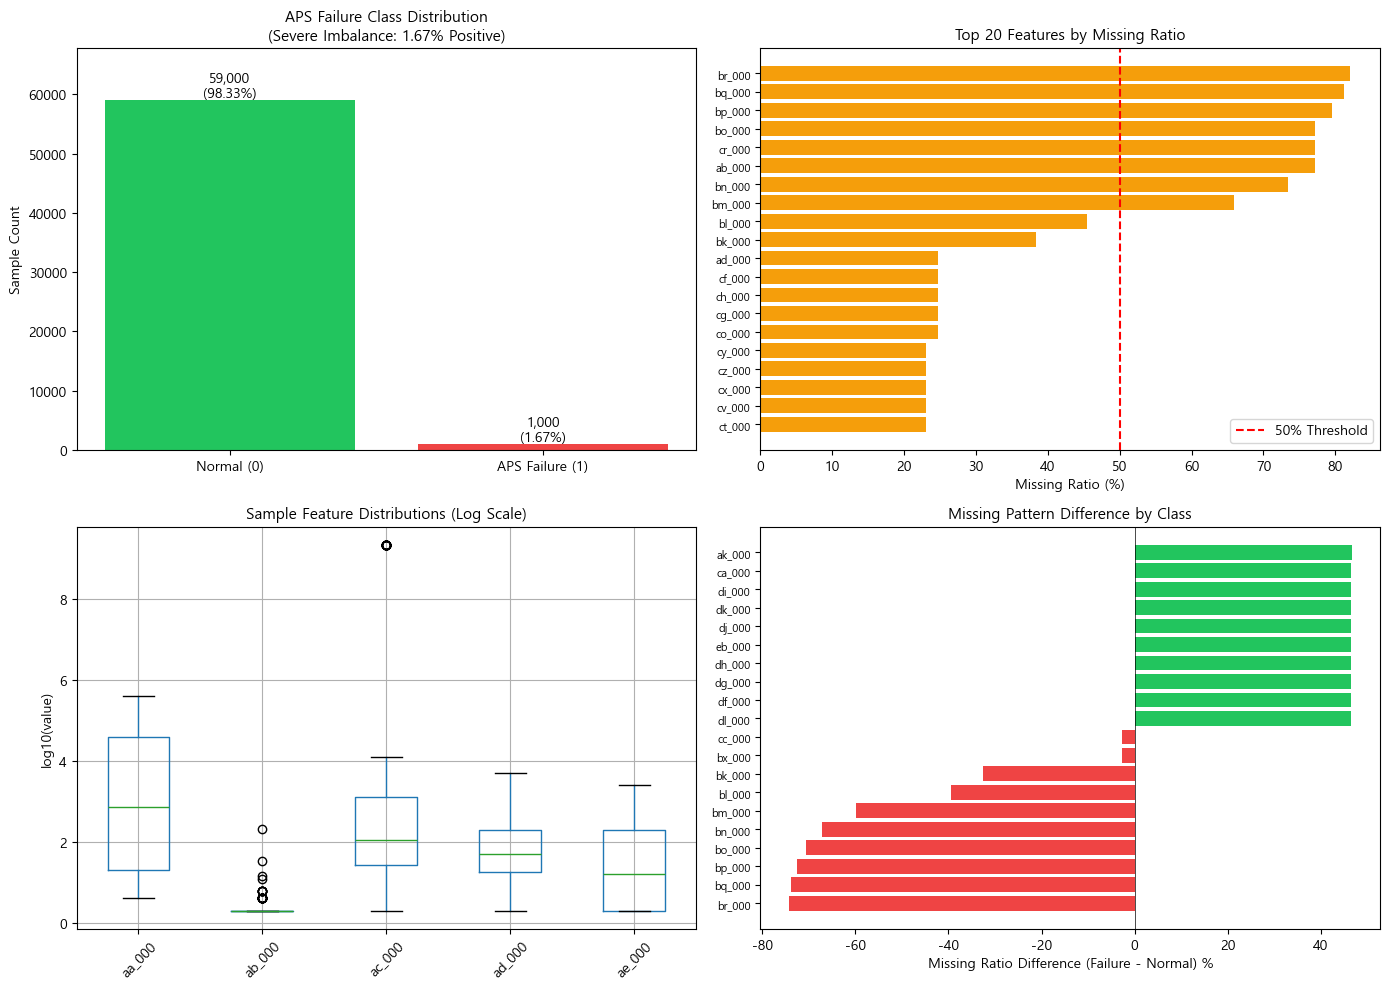


[Figure saved: 18_aps_data_overview.png]


In [4]:
# 시각화: 데이터 개요
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 클래스 분포
ax1 = axes[0, 0]
colors = ['#22c55e', '#ef4444']
bars = ax1.bar(['Normal (0)', 'APS Failure (1)'], class_counts.values, color=colors)
ax1.set_ylabel('Sample Count')
ax1.set_title('APS Failure Class Distribution\n(Severe Imbalance: 1.67% Positive)', fontsize=11)
for bar, count in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{count:,}\n({count/len(y_train_full)*100:.2f}%)', ha='center', fontsize=10)
ax1.set_ylim(0, max(class_counts.values) * 1.15)

# 2. 결측치 분포 (상위 20개)
ax2 = axes[0, 1]
top_missing = cols_with_missing.head(20)
ax2.barh(range(len(top_missing)), top_missing.values, color='#f59e0b')
ax2.set_yticks(range(len(top_missing)))
ax2.set_yticklabels(top_missing.index, fontsize=8)
ax2.set_xlabel('Missing Ratio (%)')
ax2.set_title('Top 20 Features by Missing Ratio', fontsize=11)
ax2.axvline(x=50, color='red', linestyle='--', label='50% Threshold')
ax2.legend()
ax2.invert_yaxis()

# 3. 특성 값 분포 (샘플 특성)
ax3 = axes[1, 0]
sample_features = ['aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000']
available_features = [f for f in sample_features if f in X_train_full.columns]
if available_features:
    sample_data = X_train_full[available_features].dropna()
    if len(sample_data) > 0:
        # 로그 스케일로 변환 (0보다 큰 값만)
        log_data = np.log10(sample_data[sample_data > 0].dropna())
        log_data.boxplot(ax=ax3)
        ax3.set_ylabel('log10(value)')
        ax3.set_title('Sample Feature Distributions (Log Scale)', fontsize=11)
        ax3.tick_params(axis='x', rotation=45)

# 4. 클래스별 결측치 패턴
ax4 = axes[1, 1]
missing_by_class = pd.DataFrame({
    'Normal': X_train_full[y_train_full == 0].isnull().mean() * 100,
    'APS Failure': X_train_full[y_train_full == 1].isnull().mean() * 100
})
missing_diff = (missing_by_class['APS Failure'] - missing_by_class['Normal']).sort_values()
top_diff = pd.concat([missing_diff.head(10), missing_diff.tail(10)])
colors_diff = ['#ef4444' if v < 0 else '#22c55e' for v in top_diff.values]
ax4.barh(range(len(top_diff)), top_diff.values, color=colors_diff)
ax4.set_yticks(range(len(top_diff)))
ax4.set_yticklabels(top_diff.index, fontsize=8)
ax4.set_xlabel('Missing Ratio Difference (Failure - Normal) %')
ax4.set_title('Missing Pattern Difference by Class', fontsize=11)
ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('18_aps_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Figure saved: 18_aps_data_overview.png]")

**시각화 해석:**

1. **클래스 분포**: 정상(59,000)과 고장(1,000)의 극심한 불균형 (약 59:1). 이러한 불균형 데이터에서는 단순 정확도(Accuracy) 대신 F1-Score, Recall, 또는 비용 기반 평가가 필요

2. **결측치 분포**: 일부 특성은 50% 이상의 결측치 나타남. 이러한 특성은 정보량이 부족하므로 제거를 고려

3. **특성 값 범위**: 특성들의 스케일이 매우 다양하게 나타남(로그 스케일로 표시). StandardScaler 적용이 필요

4. **클래스별 결측치 패턴**: 일부 특성은 고장 샘플에서 결측치가 더 많거나 적음. 이는 결측치 자체가 정보를 담고 있을 수 있음을 시사

## 2.2 데이터 전처리

In [5]:
print("=" * 70)
print("데이터 전처리")
print("=" * 70)

# 1. 결측치가 너무 많은 열 제거 (50% 이상)
missing_threshold = 0.5
cols_to_drop = missing_per_col[missing_per_col > missing_threshold * 100].index
X_train_filtered = X_train_full.drop(columns=cols_to_drop)
X_test_filtered = X_test.drop(columns=cols_to_drop)

print(f"\n[1단계: 결측치 50% 이상 열 제거]")
print(f"   제거된 열: {len(cols_to_drop)}개")
print(f"   남은 특성 수: {X_train_filtered.shape[1]}개")

# 2. 분산이 0인 열 제거 (상수 열)
variance = X_train_filtered.var()
cols_zero_var = variance[variance == 0].index
X_train_filtered = X_train_filtered.drop(columns=cols_zero_var)
X_test_filtered = X_test_filtered.drop(columns=cols_zero_var)

print(f"\n[2단계: 분산 0인 열 제거]")
print(f"   제거된 열: {len(cols_zero_var)}개")
print(f"   남은 특성 수: {X_train_filtered.shape[1]}개")

# 3. 학습 데이터에서 검증용 분리 (학습 시간 단축을 위해 샘플링)
# 전체 데이터 사용 시 시간이 오래 걸리므로, 실습용으로 샘플링
SAMPLE_SIZE = 20000  # 학습용 샘플 수
X_train_sampled, _, y_train_sampled, _ = train_test_split(
    X_train_filtered, y_train_full,
    train_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print(f"\n[3단계: 학습 데이터 샘플링 (실습 시간 단축)]")
print(f"   원본 학습 데이터: {len(X_train_filtered):,}개")
print(f"   샘플링된 학습 데이터: {len(X_train_sampled):,}개")
print(f"   샘플링 후 고장 비율: {y_train_sampled.mean()*100:.2f}%")

# 4. 학습/검증 분할
X_train, X_val, y_train, y_val = train_test_split(
    X_train_sampled, y_train_sampled,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_sampled
)

print(f"\n[4단계: 학습/검증 분할]")
print(f"   학습 데이터: {len(X_train):,}개")
print(f"   검증 데이터: {len(X_val):,}개")

# 5. 전처리 파이프라인 생성
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # 결측치를 중앙값으로 대체
    ('scaler', StandardScaler())  # 표준화
])

# 전처리 적용
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test_filtered)

print(f"\n[5단계: 전처리 완료]")
print(f"   결측치 처리: 중앙값(Median) 대체")
print(f"   스케일링: StandardScaler (평균 0, 표준편차 1)")
print(f"   최종 특성 수: {X_train_processed.shape[1]}개")

데이터 전처리

[1단계: 결측치 50% 이상 열 제거]
   제거된 열: 8개
   남은 특성 수: 162개

[2단계: 분산 0인 열 제거]
   제거된 열: 1개
   남은 특성 수: 161개

[3단계: 학습 데이터 샘플링 (실습 시간 단축)]
   원본 학습 데이터: 60,000개
   샘플링된 학습 데이터: 20,000개
   샘플링 후 고장 비율: 1.67%

[4단계: 학습/검증 분할]
   학습 데이터: 16,000개
   검증 데이터: 4,000개

[5단계: 전처리 완료]
   결측치 처리: 중앙값(Median) 대체
   스케일링: StandardScaler (평균 0, 표준편차 1)
   최종 특성 수: 161개


## 2.3 비용 기반 평가 함수 정의

APS Failure 데이터셋의 핵심은 **비용 기반 평가**. 단순 정확도나 F1-Score 외에도 실제 비즈니스 비용을 반영한 평가 지표를 사용가능함

In [6]:
# 비용 함수 정의
COST_FP = 10    # False Positive: 불필요한 정비 비용
COST_FN = 500   # False Negative: 운행 중 고장 비용 (50배)

def calculate_total_cost(y_true, y_pred):
    """
    Scania APS Failure 비용 함수
    Total Cost = 10 * FP + 500 * FN
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_cost = COST_FP * fp + COST_FN * fn
    return total_cost

def cost_scorer(y_true, y_pred):
    """
    sklearn 호환 비용 점수 함수 (낮을수록 좋음, 음수로 반환하여 최대화 문제로 변환)
    """
    return -calculate_total_cost(y_true, y_pred)

# sklearn scorer 생성
cost_scorer_sklearn = make_scorer(cost_scorer, greater_is_better=True)

print("[비용 함수 정의]")
print(f"  False Positive (불필요 정비) 비용: ${COST_FP}")
print(f"  False Negative (고장 누락) 비용: ${COST_FN}")
print(f"  비용 비율: FN/FP = {COST_FN/COST_FP}배")
print(f"\n  -> 고장을 놓치는 것이 불필요한 정비보다 50배 더 비쌈")
print(f"  -> Recall (고장 탐지율)이 매우 중요!")

[비용 함수 정의]
  False Positive (불필요 정비) 비용: $10
  False Negative (고장 누락) 비용: $500
  비용 비율: FN/FP = 50.0배

  -> 고장을 놓치는 것이 불필요한 정비보다 50배 더 비쌈
  -> Recall (고장 탐지율)이 매우 중요!


# Part 3: 기본 모델 성능 측정 (Baseline)

하이퍼파라미터 튜닝의 효과를 측정하려면 먼저 **기본 설정(Baseline)** 의 성능을 파악해야 함

In [7]:
print("=" * 70)
print("Part 3: 기본 모델 성능 측정 (튜닝 전)")
print("=" * 70)

# 기본 설정 RandomForest
model_default = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("\n[기본 RandomForest 설정]")
print(f"  n_estimators: {model_default.n_estimators} (기본값)")
print(f"  max_depth: {model_default.max_depth} (기본값 = None, 무제한)")
print(f"  min_samples_split: {model_default.min_samples_split} (기본값)")
print(f"  class_weight: {model_default.class_weight} (기본값)")

# 교차검증 수행
print("\n[교차검증 수행 중...]")
cv_f1_default = cross_val_score(
    model_default, X_train_processed, y_train,
    cv=5, scoring='f1', n_jobs=-1
)

print(f"\n[교차검증 결과 - F1 Score]")
print(f"  각 Fold: {[f'{s:.3f}' for s in cv_f1_default]}")
print(f"  평균: {cv_f1_default.mean():.3f} (+/- {cv_f1_default.std():.3f})")

# 전체 학습 데이터로 학습 후 검증 데이터 평가
model_default.fit(X_train_processed, y_train)
y_val_pred_default = model_default.predict(X_val_processed)

# 성능 지표 계산
f1_default = f1_score(y_val, y_val_pred_default)
recall_default = recall_score(y_val, y_val_pred_default)
precision_default = precision_score(y_val, y_val_pred_default)
cost_default = calculate_total_cost(y_val, y_val_pred_default)

print(f"\n[검증 데이터 성능]")
print(f"  F1 Score: {f1_default:.3f}")
print(f"  Recall (고장 탐지율): {recall_default:.3f}")
print(f"  Precision: {precision_default:.3f}")
print(f"  Total Cost: ${cost_default:,}")

# 혼동 행렬
cm_default = confusion_matrix(y_val, y_val_pred_default)
tn, fp, fn, tp = cm_default.ravel()
print(f"\n[혼동 행렬]")
print(f"  True Negative (정상을 정상으로): {tn:,}")
print(f"  False Positive (정상을 고장으로): {fp:,} -> 비용: ${fp * COST_FP:,}")
print(f"  False Negative (고장을 정상으로): {fn:,} -> 비용: ${fn * COST_FN:,}")
print(f"  True Positive (고장을 고장으로): {tp:,}")

Part 3: 기본 모델 성능 측정 (튜닝 전)

[기본 RandomForest 설정]
  n_estimators: 100 (기본값)
  max_depth: None (기본값 = None, 무제한)
  min_samples_split: 2 (기본값)
  class_weight: None (기본값)

[교차검증 수행 중...]

[교차검증 결과 - F1 Score]
  각 Fold: ['0.667', '0.733', '0.688', '0.783', '0.674']
  평균: 0.709 (+/- 0.044)

[검증 데이터 성능]
  F1 Score: 0.709
  Recall (고장 탐지율): 0.582
  Precision: 0.907
  Total Cost: $14,040

[혼동 행렬]
  True Negative (정상을 정상으로): 3,929
  False Positive (정상을 고장으로): 4 -> 비용: $40
  False Negative (고장을 정상으로): 28 -> 비용: $14,000
  True Positive (고장을 고장으로): 39


# 4: GridSearchCV 적용

이제 GridSearchCV를 사용하여 체계적으로 최적의 하이퍼파라미터 조합을 검색해봄

In [8]:
print("=" * 70)
print("Part 4: GridSearchCV 실습")
print("=" * 70)

# 탐색 범위 정의
param_grid = {
    'n_estimators': [50, 100, 150],          # 트리 개수
    'max_depth': [5, 10, 15, None],          # 트리 깊이
    'min_samples_split': [2, 5, 10],         # 분할 최소 샘플
    'min_samples_leaf': [1, 2, 4],           # 리프 최소 샘플
    'class_weight': ['balanced', None]      # 클래스 가중치
}

# 조합 수 계산
total_combinations = 1
print("\n[탐색 범위]")
for param, values in param_grid.items():
    print(f"  {param}: {values} ({len(values)}개)")
    total_combinations *= len(values)

print(f"\n[탐색 규모]")
print(f"  총 조합 수: {total_combinations}개")
print(f"  5-Fold CV 적용 시 학습 횟수: {total_combinations * 5}회")

# 탐색 공간 크기 수식 표현
print(f"\n[수학적 표현]")
print(f"  |S| = |P_n_estimators| x |P_max_depth| x |P_min_samples_split| x |P_min_samples_leaf| x |P_class_weight|")
print(f"      = 3 x 4 x 3 x 3 x 2 = {total_combinations}")

Part 4: GridSearchCV 실습

[탐색 범위]
  n_estimators: [50, 100, 150] (3개)
  max_depth: [5, 10, 15, None] (4개)
  min_samples_split: [2, 5, 10] (3개)
  min_samples_leaf: [1, 2, 4] (3개)
  class_weight: ['balanced', None] (2개)

[탐색 규모]
  총 조합 수: 216개
  5-Fold CV 적용 시 학습 횟수: 1080회

[수학적 표현]
  |S| = |P_n_estimators| x |P_max_depth| x |P_min_samples_split| x |P_min_samples_leaf| x |P_class_weight|
      = 3 x 4 x 3 x 3 x 2 = 216


In [9]:
# GridSearchCV 생성 및 실행
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    cv=5,                          # 5-Fold 교차검증
    scoring='f1',                  # 불균형 데이터이므로 F1 사용
    n_jobs=-1,                     # 모든 CPU 코어 사용
    verbose=1,                     # 진행 상황 출력
    return_train_score=True        # 학습 점수도 반환
)

print("\n[GridSearchCV 실행 중...]")
print("  (이 과정은 몇 분 소요될 수 있음)")

start_time = time.time()
grid_search.fit(X_train_processed, y_train)
grid_time = time.time() - start_time

print(f"\n[GridSearchCV 완료]")
print(f"  탐색 시간: {grid_time:.1f}초 ({grid_time/60:.2f}분)")
print(f"  평균 조합당 시간: {grid_time/total_combinations:.2f}초")


[GridSearchCV 실행 중...]
  (이 과정은 몇 분 소요될 수 있습니다)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

[GridSearchCV 완료]
  탐색 시간: 282.7초 (4.71분)
  평균 조합당 시간: 1.31초


In [11]:
# 결과 분석
print("\n[최적 하이퍼파라미터]")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n[최고 CV 점수 (F1)]")
print(f"  {grid_search.best_score_:.4f}")

# 결과를 DataFrame으로 변환
results_df = pd.DataFrame(grid_search.cv_results_)

# 상위 10개 조합
print(f"\n[상위 10개 조합]")
top_10 = results_df.nsmallest(10, 'rank_test_score')[[
    'rank_test_score', 'mean_test_score', 'std_test_score',
    'param_n_estimators', 'param_max_depth', 'param_class_weight'
]]
print(top_10.to_string(index=False))


[최적 하이퍼파라미터]
  class_weight: None
  max_depth: 15
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 150

[최고 CV 점수 (F1)]
  0.7353

[상위 10개 조합]
 rank_test_score  mean_test_score  std_test_score  param_n_estimators param_max_depth param_class_weight
               1         0.735282        0.032708                 150              15               None
               2         0.731991        0.031020                 100              15               None
               3         0.730304        0.033347                  50              15               None
               4         0.726362        0.019668                  50              15               None
               5         0.721980        0.045482                 150            None               None
               6         0.719460        0.035345                  50            None               None
               7         0.719076        0.030208                 150            None               None
     

### GridSearchCV 결과 시각화

ValueError: The number of FixedLocator locations (1), usually from a call to set_ticks, does not match the number of labels (2).

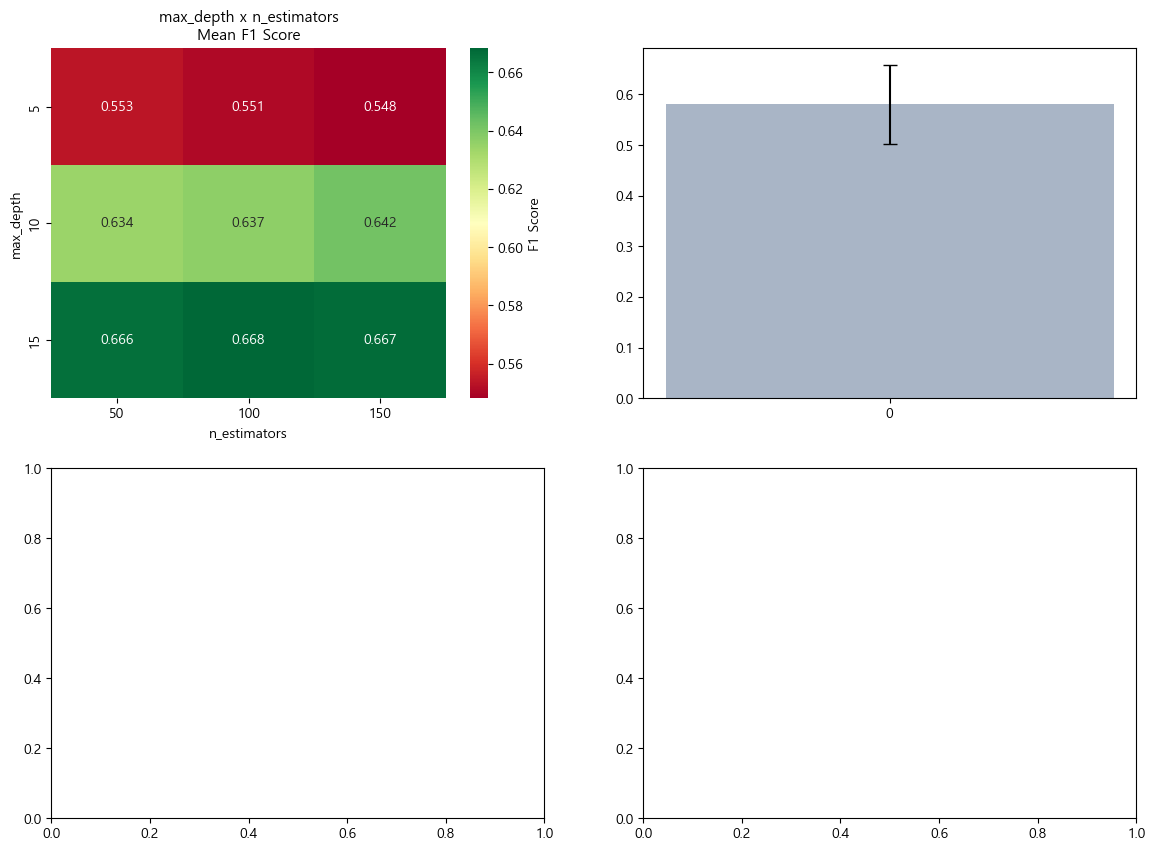

In [12]:
# 시각화: 하이퍼파라미터 영향 분석
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. max_depth x n_estimators 히트맵
ax1 = axes[0, 0]
pivot_depth_est = results_df.groupby(
    ['param_max_depth', 'param_n_estimators']
)['mean_test_score'].mean().unstack()
sns.heatmap(pivot_depth_est, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=ax1, cbar_kws={'label': 'F1 Score'})
ax1.set_xlabel('n_estimators')
ax1.set_ylabel('max_depth')
ax1.set_title('max_depth x n_estimators\nMean F1 Score', fontsize=11)

# 2. class_weight 영향
ax2 = axes[0, 1]
cw_groups = results_df.groupby('param_class_weight')['mean_test_score'].agg(['mean', 'std'])
colors_cw = ['#94a3b8', '#22c55e']
bars_cw = ax2.bar(range(len(cw_groups)), cw_groups['mean'].values,
                  yerr=cw_groups['std'].values, color=colors_cw,
                  capsize=5, alpha=0.8)
ax2.set_xticks(range(len(cw_groups)))
ax2.set_xticklabels(['None', 'balanced'])
ax2.set_ylabel('Mean CV F1 Score')
ax2.set_title('class_weight Impact\n(Imbalanced Data Handling)', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
for bar, mean in zip(bars_cw, cw_groups['mean'].values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{mean:.3f}', ha='center', fontsize=11, fontweight='bold')

# 3. max_depth별 성능 분포
ax3 = axes[1, 0]
depth_values = param_grid['max_depth']
depth_groups = []
depth_labels = []
for depth in depth_values:
    if depth is None:
        mask = results_df['param_max_depth'].isna()
        depth_labels.append('None')
    else:
        mask = results_df['param_max_depth'] == depth
        depth_labels.append(str(depth))
    depth_groups.append(results_df.loc[mask, 'mean_test_score'].values)

bp = ax3.boxplot(depth_groups, labels=depth_labels, patch_artist=True)
colors_box = plt.cm.viridis(np.linspace(0.2, 0.8, len(depth_groups)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_xlabel('max_depth')
ax3.set_ylabel('CV F1 Score')
ax3.set_title('max_depth Performance Distribution', fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

# 4. 전체 조합 성능 분포
ax4 = axes[1, 1]
ax4.hist(results_df['mean_test_score'], bins=20, color='#3b82f6',
         edgecolor='white', alpha=0.7)
ax4.axvline(x=grid_search.best_score_, color='red', linestyle='--',
            linewidth=2, label=f'Best: {grid_search.best_score_:.3f}')
ax4.axvline(x=results_df['mean_test_score'].median(), color='orange',
            linestyle='--', linewidth=2,
            label=f'Median: {results_df["mean_test_score"].median():.3f}')
ax4.set_xlabel('CV F1 Score')
ax4.set_ylabel('Combination Count')
ax4.set_title('All Combinations Performance Distribution', fontsize=11)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('18_gridsearch_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Figure saved: 18_gridsearch_results.png]")

**GridSearchCV 결과 해석:**

1. **max_depth x n_estimators 히트맵**: 어떤 조합에서 가장 높은 F1 Score를 달성하는지 한눈에 파악할 수 있음. 일반적으로 트리 개수(n_estimators)가 많을수록, 적절한 깊이(max_depth)에서 좋은 성능을 보일 것.

2. **class_weight 영향**: 불균형 데이터에서 `class_weight='balanced'` 옵션이 얼마나 효과적인지 확인할 수 있음. 이 옵션은 소수 클래스(고장)에 더 높은 가중치를 부여하여 이전 문제를 완화함.

3. **max_depth별 분포**: 박스플롯으로 각 max_depth 값에서의 성능 분포를 확인. 분포가 좁고 중앙값이 높은 값이 안정적인 선택.

4. **전체 분포**: 대부분의 조합이 어느 정도의 성능을 보이는지, 최적값과 중앙값의 차이가 얼마나 되는지 파악할 수 있음.

# 5. RandomizedSearchCV 적용

더 넓은 탐색 공간에서 효율적으로 좋은 하이퍼파라미터를 찾기 위해 RandomizedSearchCV를 사용.

In [13]:
print("=" * 70)
print("Part 5: RandomizedSearchCV 실습")
print("=" * 70)

# 분포 기반 탐색 범위 정의 (더 넓은 범위)
param_distributions = {
    'n_estimators': randint(50, 300),           # 50~299 정수 균등 분포
    'max_depth': [5, 7, 10, 15, 20, 25, None],  # 리스트 (이산 값)
    'min_samples_split': randint(2, 30),        # 2~29 정수 균등 분포
    'min_samples_leaf': randint(1, 15),         # 1~14 정수 균등 분포
    'max_features': ['sqrt', 'log2', None],     # 범주형
    'class_weight': ['balanced', 'balanced_subsample', None]
}

print("\n[탐색 범위 (분포 기반)]")
print("  n_estimators: randint(50, 300) - 정수 균등 분포")
print("  max_depth: [5, 7, 10, 15, 20, 25, None] - 이산 값")
print("  min_samples_split: randint(2, 30)")
print("  min_samples_leaf: randint(1, 15)")
print("  max_features: ['sqrt', 'log2', None]")
print("  class_weight: ['balanced', 'balanced_subsample', None]")

# 탐색할 조합 수
n_iter = 50
print(f"\n[탐색 규모]")
print(f"  탐색할 조합 수: {n_iter}개 (무작위 샘플링)")
print(f"  5-Fold CV 적용 시 학습 횟수: {n_iter * 5}회")
print(f"\n  참고: GridSearchCV 동일 범위면 수천~수만 조합 필요")

Part 5: RandomizedSearchCV 실습

[탐색 범위 (분포 기반)]
  n_estimators: randint(50, 300) - 정수 균등 분포
  max_depth: [5, 7, 10, 15, 20, 25, None] - 이산 값
  min_samples_split: randint(2, 30)
  min_samples_leaf: randint(1, 15)
  max_features: ['sqrt', 'log2', None]
  class_weight: ['balanced', 'balanced_subsample', None]

[탐색 규모]
  탐색할 조합 수: 50개 (무작위 샘플링)
  5-Fold CV 적용 시 학습 횟수: 250회

  참고: GridSearchCV 동일 범위면 수천~수만 조합 필요


In [14]:
# RandomizedSearchCV 생성 및 실행
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=n_iter,                 # 50개 조합만 탐색
    cv=5,
    scoring='f1',
    random_state=RANDOM_STATE,     # 재현성
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("\n[RandomizedSearchCV 실행 중...]")
start_time = time.time()
random_search.fit(X_train_processed, y_train)
random_time = time.time() - start_time

print(f"\n[RandomizedSearchCV 완료]")
print(f"  탐색 시간: {random_time:.1f}초 ({random_time/60:.2f}분)")


[RandomizedSearchCV 실행 중...]
Fitting 5 folds for each of 50 candidates, totalling 250 fits

[RandomizedSearchCV 완료]
  탐색 시간: 405.5초 (6.76분)


In [15]:
# RandomizedSearchCV 결과
print("\n[최적 하이퍼파라미터]")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n[최고 CV 점수 (F1)]")
print(f"  {random_search.best_score_:.4f}")


[최적 하이퍼파라미터]
  class_weight: None
  max_depth: None
  max_features: None
  min_samples_leaf: 4
  min_samples_split: 8
  n_estimators: 101

[최고 CV 점수 (F1)]
  0.7278


### GridSearchCV vs RandomizedSearchCV 비교

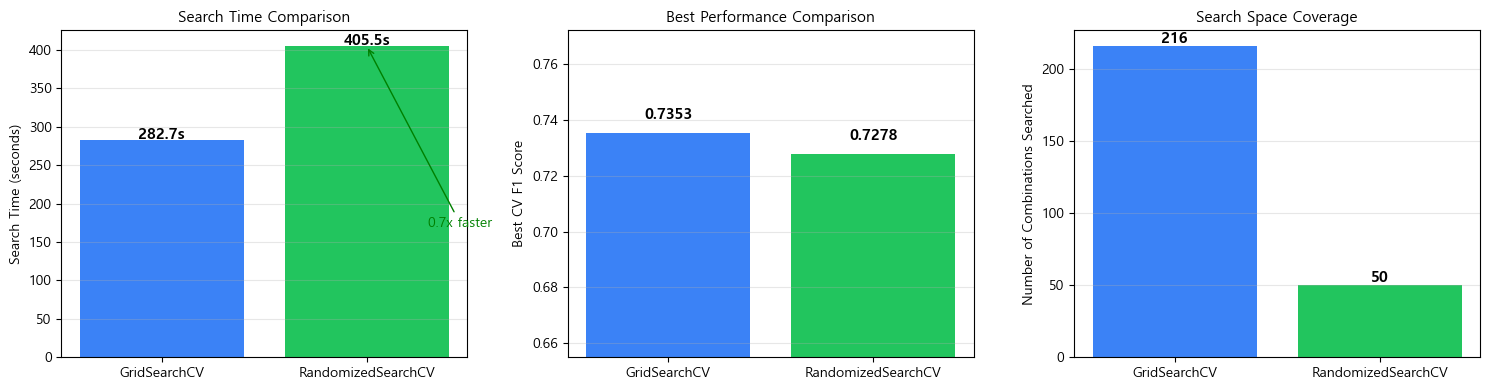


[Figure saved: 18_grid_vs_random_comparison.png]

[GridSearchCV vs RandomizedSearchCV 상세 비교]
Metric                              GridSearch    RandomSearch
--------------------------------------------------------------
Combinations Searched                      216              50
Search Time (seconds)                    282.7           405.5
Best CV F1 Score                        0.7353          0.7278
Speed (combinations/sec)                   0.8             0.1

-> RandomizedSearchCV는 0.7배 빠르게 유사한 성능 달성
-> 점수 차이: 0.0075


In [16]:
# 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

methods = ['GridSearchCV', 'RandomizedSearchCV']
colors = ['#3b82f6', '#22c55e']

# 1. 탐색 시간 비교
ax1 = axes[0]
times = [grid_time, random_time]
bars1 = ax1.bar(methods, times, color=colors)
ax1.set_ylabel('Search Time (seconds)')
ax1.set_title('Search Time Comparison', fontsize=11)
for bar, t in zip(bars1, times):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{t:.1f}s', ha='center', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 속도 향상률
if random_time > 0:
    speedup = grid_time / random_time
    ax1.annotate(f'{speedup:.1f}x faster',
                 xy=(1, random_time), xytext=(1.3, grid_time * 0.6),
                 fontsize=10, color='green',
                 arrowprops=dict(arrowstyle='->', color='green'))

# 2. CV 점수 비교
ax2 = axes[1]
cv_scores = [grid_search.best_score_, random_search.best_score_]
bars2 = ax2.bar(methods, cv_scores, color=colors)
ax2.set_ylabel('Best CV F1 Score')
ax2.set_title('Best Performance Comparison', fontsize=11)
ax2.set_ylim(min(cv_scores) * 0.9, max(cv_scores) * 1.05)
for bar, score in zip(bars2, cv_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.4f}', ha='center', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 3. 탐색 조합 수 비교
ax3 = axes[2]
combinations = [total_combinations, n_iter]
bars3 = ax3.bar(methods, combinations, color=colors)
ax3.set_ylabel('Number of Combinations Searched')
ax3.set_title('Search Space Coverage', fontsize=11)
for bar, comb in zip(bars3, combinations):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{comb}', ha='center', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('18_grid_vs_random_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Figure saved: 18_grid_vs_random_comparison.png]")

# 수치 비교 테이블
print("\n[GridSearchCV vs RandomizedSearchCV 상세 비교]")
print(f"{'Metric':<30} {'GridSearch':>15} {'RandomSearch':>15}")
print("-" * 62)
print(f"{'Combinations Searched':<30} {total_combinations:>15} {n_iter:>15}")
print(f"{'Search Time (seconds)':<30} {grid_time:>15.1f} {random_time:>15.1f}")
print(f"{'Best CV F1 Score':<30} {grid_search.best_score_:>15.4f} {random_search.best_score_:>15.4f}")
print(f"{'Speed (combinations/sec)':<30} {total_combinations/grid_time:>15.1f} {n_iter/random_time:>15.1f}")
if random_time > 0:
    print(f"\n-> RandomizedSearchCV는 {speedup:.1f}배 빠르게 유사한 성능 달성")
    print(f"-> 점수 차이: {abs(grid_search.best_score_ - random_search.best_score_):.4f}")

# 검증 곡선과 학습 곡선

검증 곡선(Validation Curve)과 학습 곡선(Learning Curve)을 통해 하이퍼파라미터의 영향과 모델의 학습 특성을 시각적으로 분석할 수 있음

In [17]:
print("=" * 70)
print("Part 6: 검증 곡선과 학습 곡선 분석")
print("=" * 70)

# 검증 곡선: max_depth
print("\n[검증 곡선 생성 중 - max_depth...]")
param_range_depth = [3, 5, 7, 10, 15, 20, 25]

train_scores_depth, valid_scores_depth = validation_curve(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE,
                          class_weight='balanced', n_jobs=-1),
    X_train_processed, y_train,
    param_name='max_depth',
    param_range=param_range_depth,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("[검증 곡선 생성 중 - n_estimators...]")
param_range_est = [10, 30, 50, 100, 150, 200]

train_scores_est, valid_scores_est = validation_curve(
    RandomForestClassifier(max_depth=10, random_state=RANDOM_STATE,
                          class_weight='balanced', n_jobs=-1),
    X_train_processed, y_train,
    param_name='n_estimators',
    param_range=param_range_est,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("완료!")

Part 6: 검증 곡선과 학습 곡선 분석

[검증 곡선 생성 중 - max_depth...]


KeyboardInterrupt: 

In [ ]:
# 검증 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. max_depth 검증 곡선
ax1 = axes[0]
train_mean_depth = train_scores_depth.mean(axis=1)
train_std_depth = train_scores_depth.std(axis=1)
valid_mean_depth = valid_scores_depth.mean(axis=1)
valid_std_depth = valid_scores_depth.std(axis=1)

ax1.plot(param_range_depth, train_mean_depth, 'o-', color='#3b82f6',
         label='Training Score', linewidth=2, markersize=8)
ax1.fill_between(param_range_depth, train_mean_depth - train_std_depth,
                 train_mean_depth + train_std_depth, alpha=0.2, color='#3b82f6')
ax1.plot(param_range_depth, valid_mean_depth, 'o-', color='#ef4444',
         label='Validation Score', linewidth=2, markersize=8)
ax1.fill_between(param_range_depth, valid_mean_depth - valid_std_depth,
                 valid_mean_depth + valid_std_depth, alpha=0.2, color='#ef4444')

# 최적 지점 표시
best_idx_depth = np.argmax(valid_mean_depth)
ax1.axvline(x=param_range_depth[best_idx_depth], color='green', linestyle='--',
            alpha=0.7, label=f'Best: {param_range_depth[best_idx_depth]}')
ax1.scatter([param_range_depth[best_idx_depth]], [valid_mean_depth[best_idx_depth]],
            s=200, c='green', marker='*', zorder=5)

ax1.set_xlabel('max_depth')
ax1.set_ylabel('F1 Score')
ax1.set_title('Validation Curve: max_depth\n(Train-Validation Gap = Overfitting)', fontsize=11)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# 2. n_estimators 검증 곡선
ax2 = axes[1]
train_mean_est = train_scores_est.mean(axis=1)
train_std_est = train_scores_est.std(axis=1)
valid_mean_est = valid_scores_est.mean(axis=1)
valid_std_est = valid_scores_est.std(axis=1)

ax2.plot(param_range_est, train_mean_est, 'o-', color='#3b82f6',
         label='Training Score', linewidth=2, markersize=8)
ax2.fill_between(param_range_est, train_mean_est - train_std_est,
                 train_mean_est + train_std_est, alpha=0.2, color='#3b82f6')
ax2.plot(param_range_est, valid_mean_est, 'o-', color='#ef4444',
         label='Validation Score', linewidth=2, markersize=8)
ax2.fill_between(param_range_est, valid_mean_est - valid_std_est,
                 valid_mean_est + valid_std_est, alpha=0.2, color='#ef4444')

ax2.set_xlabel('n_estimators')
ax2.set_ylabel('F1 Score')
ax2.set_title('Validation Curve: n_estimators\n(Diminishing Returns)', fontsize=11)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('18_validation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Figure saved: 18_validation_curves.png]")

**검증 곡선 해석:**

1. **max_depth 곡선**:
   - 학습 점수와 검증 점수의 **격차**가 커지는 지점이 **과대적합**의 시작
   - max_depth가 너무 작으면 과소적합(둘 다 낮음), 너무 크면 과대적합(격차 큼)
   - 최적 지점은 검증 점수가 최대인 곳

2. **n_estimators 곡선**:
   - 트리 개수가 증가해도 일정 수준 이상에서는 성능 향상이 미미(**수확체감**)
   - 더 많은 트리는 계산 비용만 증가시킴
   - 적절한 트리 개수를 선택하여 효율성 확보

In [ ]:
# 학습 곡선: 데이터 양에 따른 성능 변화
print("\n[학습 곡선 생성 중...]")

# 최적 모델로 학습 곡선 생성
best_model = grid_search.best_estimator_

train_sizes_abs, train_scores_lc, valid_scores_lc = learning_curve(
    best_model,
    X_train_processed, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

print("완료!")

In [ ]:
# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 학습 곡선
ax1 = axes[0]
train_mean_lc = train_scores_lc.mean(axis=1)
train_std_lc = train_scores_lc.std(axis=1)
valid_mean_lc = valid_scores_lc.mean(axis=1)
valid_std_lc = valid_scores_lc.std(axis=1)

ax1.plot(train_sizes_abs, train_mean_lc, 'o-', color='#3b82f6',
         label='Training Score', linewidth=2, markersize=8)
ax1.fill_between(train_sizes_abs, train_mean_lc - train_std_lc,
                 train_mean_lc + train_std_lc, alpha=0.2, color='#3b82f6')
ax1.plot(train_sizes_abs, valid_mean_lc, 'o-', color='#ef4444',
         label='Validation Score', linewidth=2, markersize=8)
ax1.fill_between(train_sizes_abs, valid_mean_lc - valid_std_lc,
                 valid_mean_lc + valid_std_lc, alpha=0.2, color='#ef4444')

ax1.set_xlabel('Training Set Size')
ax1.set_ylabel('F1 Score')
ax1.set_title('Learning Curve (Best Model)\nWould More Data Help?', fontsize=11)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# 2. 학습-검증 격차
ax2 = axes[1]
gap = train_mean_lc - valid_mean_lc
colors_gap = ['#22c55e' if g < 0.05 else '#f59e0b' if g < 0.1 else '#ef4444' for g in gap]
bars_gap = ax2.bar(range(len(train_sizes_abs)), gap, color=colors_gap, alpha=0.7)
ax2.set_xticks(range(len(train_sizes_abs)))
ax2.set_xticklabels([f'{int(s)}' for s in train_sizes_abs], rotation=45)
ax2.set_xlabel('Training Set Size')
ax2.set_ylabel('Train-Validation Gap')
ax2.set_title('Overfitting Analysis\n(Larger Gap = More Overfitting)', fontsize=11)
ax2.axhline(y=0.05, color='orange', linestyle='--', label='Warning (0.05)')
ax2.axhline(y=0.1, color='red', linestyle='--', label='Critical (0.1)')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('18_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Figure saved: 18_learning_curves.png]")

**학습 곡선 해석:**

1. **수렴 패턴**: 두 곡선이 수렴하면 현재 데이터 양이 충분함을 의미
2. **격차 유지**: 데이터가 늘어도 격차가 유지되면 모델 복잡도 조정 필요
3. **격차 감소**: 데이터 증가에 따라 격차가 줄어들면 추가 데이터 수집이 도움됨
4. **색상 코드**: 녹색(양호) < 주황색(주의) < 빨간색(과적합)

# 최종 결과 비교 및 평가

튜닝 전후의 성능을 최종 테스트 데이터에서 비교하고, 비용 관점에서 개선 효과를 분석

In [ ]:
print("=" * 70)
print("Part 7: 최종 결과 비교 및 평가")
print("=" * 70)

# 최적 모델로 테스트 데이터 예측
best_model_grid = grid_search.best_estimator_
best_model_random = random_search.best_estimator_

# 검증 데이터 예측 (비교용)
y_val_pred_grid = best_model_grid.predict(X_val_processed)
y_val_pred_random = best_model_random.predict(X_val_processed)

# 테스트 데이터 예측
y_test_pred_default = model_default.predict(X_test_processed)
y_test_pred_grid = best_model_grid.predict(X_test_processed)
y_test_pred_random = best_model_random.predict(X_test_processed)

# 성능 지표 계산
results = {
    'Model': ['Default', 'GridSearchCV', 'RandomizedSearchCV'],
    'F1 Score': [
        f1_score(y_test, y_test_pred_default),
        f1_score(y_test, y_test_pred_grid),
        f1_score(y_test, y_test_pred_random)
    ],
    'Recall': [
        recall_score(y_test, y_test_pred_default),
        recall_score(y_test, y_test_pred_grid),
        recall_score(y_test, y_test_pred_random)
    ],
    'Precision': [
        precision_score(y_test, y_test_pred_default),
        precision_score(y_test, y_test_pred_grid),
        precision_score(y_test, y_test_pred_random)
    ],
    'Total Cost ($)': [
        calculate_total_cost(y_test, y_test_pred_default),
        calculate_total_cost(y_test, y_test_pred_grid),
        calculate_total_cost(y_test, y_test_pred_random)
    ]
}

results_df_final = pd.DataFrame(results)
print("\n[테스트 데이터 성능 비교]")
print(results_df_final.to_string(index=False))

In [ ]:
# 혼동 행렬 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

predictions = [
    ('Default Model', y_test_pred_default),
    ('GridSearchCV', y_test_pred_grid),
    ('RandomizedSearchCV', y_test_pred_random)
]

for ax, (title, y_pred) in zip(axes, predictions):
    cm = confusion_matrix(y_test, y_pred)
    cost = calculate_total_cost(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Failure'],
                yticklabels=['Normal', 'Failure'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{title}\nF1: {f1:.3f} | Cost: ${cost:,}', fontsize=10)

plt.tight_layout()
plt.savefig('18_confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Figure saved: 18_confusion_matrices_comparison.png]")

In [ ]:
# 성능 비교 바 차트
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

metrics = ['F1 Score', 'Recall', 'Precision', 'Total Cost ($)']
colors_models = ['#94a3b8', '#3b82f6', '#22c55e']

for ax, metric in zip(axes, metrics):
    values = results_df_final[metric].values
    bars = ax.bar(results_df_final['Model'], values, color=colors_models)
    ax.set_ylabel(metric)
    ax.set_title(metric, fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    
    # 값 표시
    for bar, val in zip(bars, values):
        if metric == 'Total Cost ($)':
            label = f'${val:,.0f}'
        else:
            label = f'{val:.3f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.02,
                label, ha='center', fontsize=9, fontweight='bold')
    
    # 비용의 경우 낮을수록 좋음
    if metric == 'Total Cost ($)':
        ax.set_ylim(0, max(values) * 1.15)
    else:
        ax.set_ylim(min(values) * 0.9, max(values) * 1.1)
    
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('18_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Figure saved: 18_performance_comparison.png]")

In [ ]:
# 비용 분석 상세
print("\n" + "=" * 70)
print("비용 기반 상세 분석")
print("=" * 70)

for i, (model_name, y_pred) in enumerate(predictions):
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    cost_fp = fp * COST_FP
    cost_fn = fn * COST_FN
    total_cost = cost_fp + cost_fn
    
    print(f"\n[{model_name}]")
    print(f"  True Positive (고장 정탐): {tp}")
    print(f"  True Negative (정상 정탐): {tn:,}")
    print(f"  False Positive (불필요 정비): {fp} x ${COST_FP} = ${cost_fp:,}")
    print(f"  False Negative (고장 누락): {fn} x ${COST_FN} = ${cost_fn:,}")
    print(f"  ----------------------------------------")
    print(f"  Total Cost: ${total_cost:,}")

# 개선 효과 계산
cost_default = calculate_total_cost(y_test, y_test_pred_default)
cost_grid = calculate_total_cost(y_test, y_test_pred_grid)
cost_random = calculate_total_cost(y_test, y_test_pred_random)

print(f"\n[비용 절감 효과]")
if cost_default > cost_grid:
    savings_grid = cost_default - cost_grid
    savings_pct_grid = savings_grid / cost_default * 100
    print(f"  GridSearchCV: ${savings_grid:,} 절감 ({savings_pct_grid:.1f}%)")
else:
    print(f"  GridSearchCV: 비용 증가 ${cost_grid - cost_default:,}")

if cost_default > cost_random:
    savings_random = cost_default - cost_random
    savings_pct_random = savings_random / cost_default * 100
    print(f"  RandomizedSearchCV: ${savings_random:,} 절감 ({savings_pct_random:.1f}%)")
else:
    print(f"  RandomizedSearchCV: 비용 증가 ${cost_random - cost_default:,}")

---

# Part 8: 요약 및 실무 가이드라인

## 핵심 정리

| 개념 | 설명 |
|------|------|
| **하이퍼파라미터** | 학습 전에 사람이 설정하는 값 (max_depth, n_estimators, learning_rate 등) |
| **탐색 공간** | $|S| = \prod_{i=1}^{k}|P_i|$ - 조합 수가 기하급수적으로 증가 |
| **GridSearchCV** | 모든 조합 철저 탐색 (확실하지만 느림) |
| **RandomizedSearchCV** | 랜덤 샘플링 (효율적, 연속 분포 지원) |
| **교차검증 평균** | $\bar{CV} = \frac{1}{k}\sum_{i=1}^{k}Score_i$ - 안정적인 성능 추정 |
| **검증 곡선** | 특정 파라미터 값에 따른 과적합/과소적합 진단 |
| **학습 곡선** | 데이터 양에 따른 성능 변화 및 추가 데이터 필요성 판단 |

## 실무 적용 체크리스트

| 단계 | 작업 | 주의사항 |
|:----:|------|----------|
| 1 | 데이터 전처리 완료 | 결측치, 스케일링, 불균형 처리 먼저 |
| 2 | 기본 모델 성능 측정 | 베이스라인 확보 (개선 효과 측정 기준) |
| 3 | 탐색 범위 설정 | 너무 넓으면 시간 낭비, 너무 좁으면 최적값 놓침 |
| 4 | 평가 지표 선택 | 문제 유형과 비즈니스 목표에 맞게 |
| 5 | RandomSearch 선실행 | 넓은 범위 빠르게 탐색 |
| 6 | GridSearch 정밀 탐색 | 유망 영역 세밀히 탐색 |
| 7 | 최종 테스트 평가 | 과적합 여부 확인 (테스트 데이터는 마지막에만!) |